# Project Title

#### `Student Performance Prediction Using Machine Learning`

* Dataset Used: student-mat.csv

* Target Variable: G3 (Final Grade)

# 1. Project Objective

The objective of this project is to build a machine learning model that predicts student academic performance based on demographic, social, and academic factors. The project also aims to perform data analysis, evaluate multiple machine learning algorithms, and deploy the final model using Streamlit as an interactive web application.

This project covers:

* Data Loading
* Data Cleaning
* Exploratory Data Analysis (EDA)
* Feature Engineering
* Feature Selection
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Streamlit Deployment
* GitHub Version Control

# 2. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 3. Data Loading

In [6]:

import pandas as pd 

df = pd.read_csv("D:\student-performance-predictor\data\student-mat.csv", sep = ";" )

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# 4. Initial Data Exploration

In [8]:
# Shape of dataset
df.shape

(395, 33)

In [9]:
# Information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [10]:
# Statistical summary
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [11]:
# Check missing values
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

# Findings

* Dataset contains 395 rows and 33 columns.
* No major missing values were found.
* Most features are categorical.
* G1, G2, and study-related features strongly influence G3.

# 5. DATA CLEANING AND TRANSFORMATION



## Encode Categorical Variables

In [15]:
# Copy dataset
clean_df = df.copy()

# Label Encoding
le = LabelEncoder()

for col in clean_df.columns:
    if clean_df[col].dtype == 'str':
        clean_df[col] = le.fit_transform(clean_df[col])

In [16]:
clean_df.dtypes

school        int64
sex           int64
age           int64
address       int64
famsize       int64
Pstatus       int64
Medu          int64
Fedu          int64
Mjob          int64
Fjob          int64
reason        int64
guardian      int64
traveltime    int64
studytime     int64
failures      int64
schoolsup     int64
famsup        int64
paid          int64
activities    int64
nursery       int64
higher        int64
internet      int64
romantic      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

## Feature Scaling

In [17]:
# Separate features and target
X = clean_df.drop('G3', axis=1)
y = clean_df['G3']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Exploratory Data Analysis (EDA)

## Distribution of Final Grades

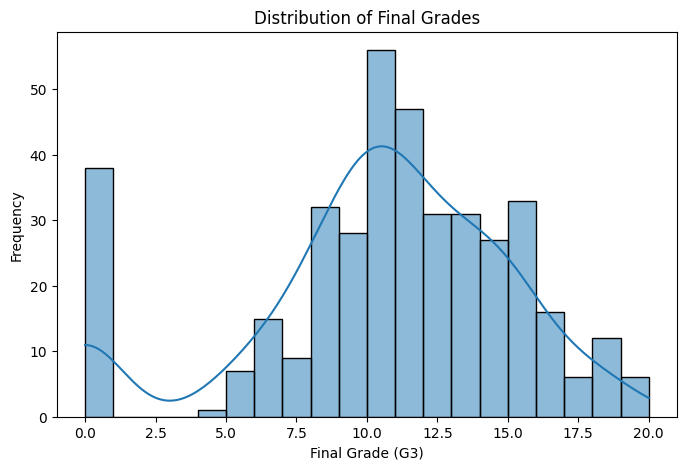

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

## Correlation Heatmap

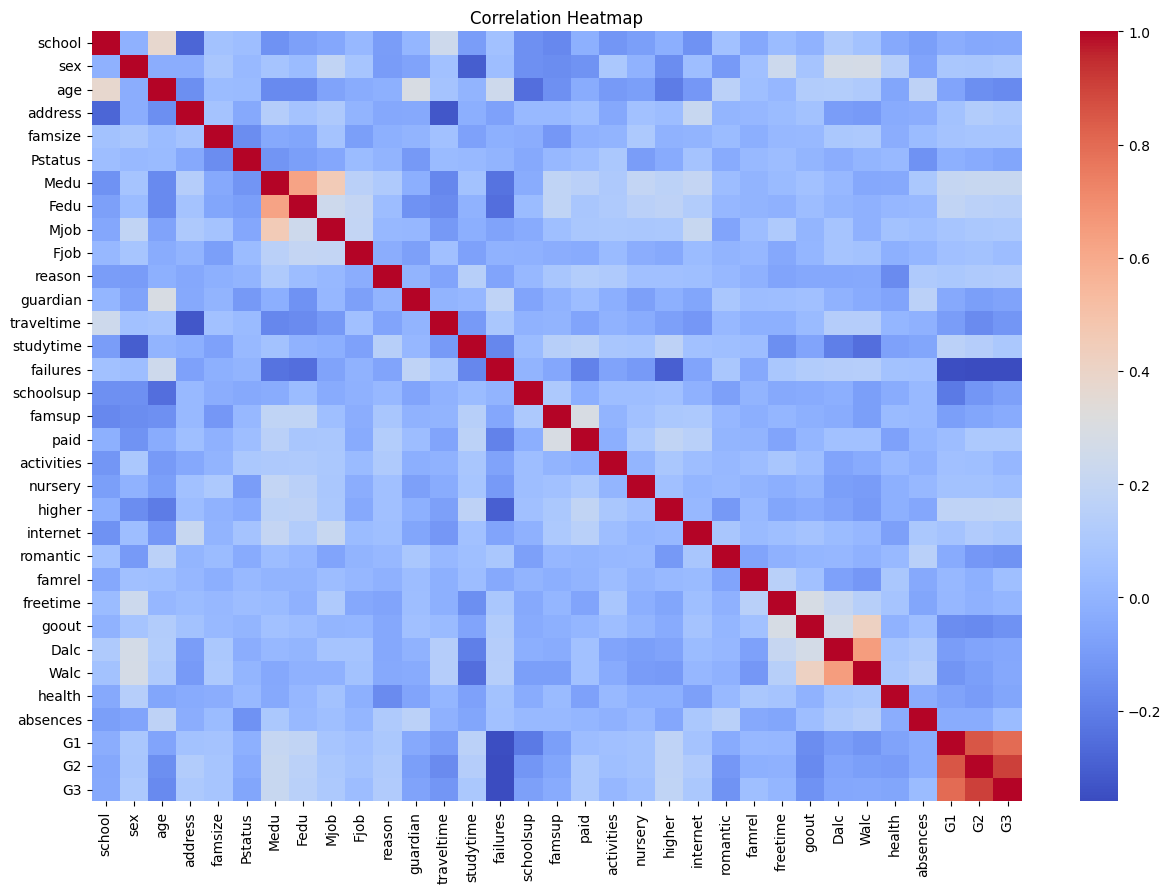

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(clean_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Relationship Between Study Time and Final Grade

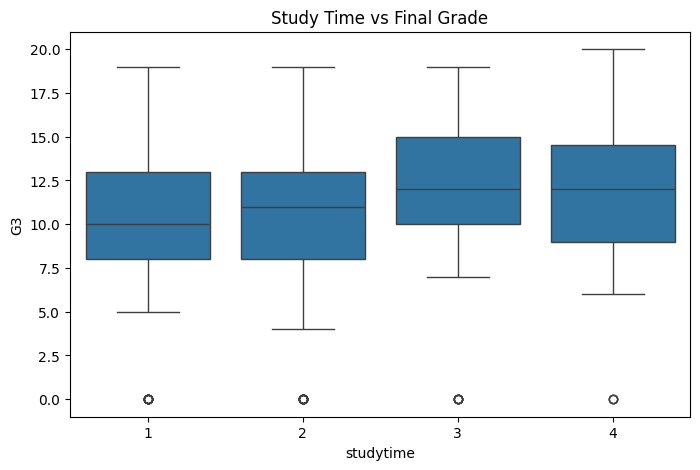

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['studytime'], y=df['G3'])
plt.title('Study Time vs Final Grade')
plt.show()

## Relationship Between Absences and Final Grade

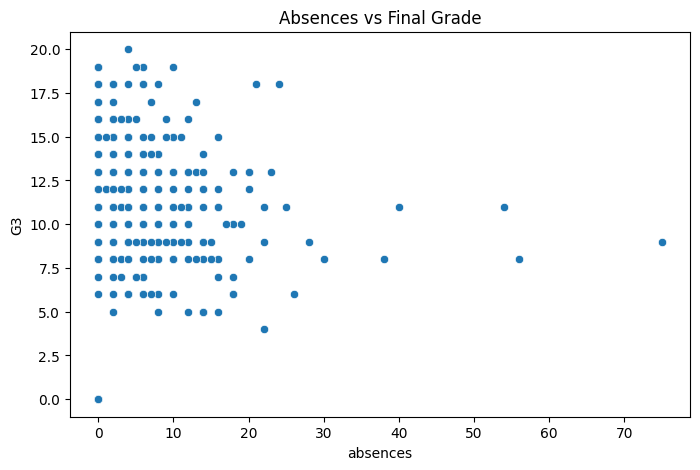

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['absences'], y=df['G3'])
plt.title('Absences vs Final Grade')
plt.show()

# 7. EDA Summary

* Key Insights

1. Students with higher G1 and G2 scores usually achieve higher final grades.
2. Excessive absences negatively affect performance.
3. Students who spend more time studying tend to score better.
4. Alcohol consumption (Dalc, Walc) slightly impacts academic performance.
5. Parental education level also influences grades.

# 8. Feature Selection

## Correlation with Target Variable

In [23]:
correlation = clean_df.corr()['G3'].sort_values(ascending=False)
correlation

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
higher        0.182465
Fedu          0.152457
reason        0.121994
address       0.105756
sex           0.103456
Mjob          0.102082
paid          0.101996
internet      0.098483
studytime     0.097820
famsize       0.081407
nursery       0.051568
famrel        0.051363
Fjob          0.042286
absences      0.034247
activities    0.016100
freetime      0.011307
famsup       -0.039157
school       -0.045017
Walc         -0.051939
Dalc         -0.054660
Pstatus      -0.058009
health       -0.061335
guardian     -0.070109
schoolsup    -0.082788
traveltime   -0.117142
romantic     -0.129970
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

## Most Important Features

### Important features identified:

* G2
* G1
* studytime
* failures
* absences
* Medu
* Fedu

# 9. Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# 10. Model Development

 ## Linear Regression

In [27]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

## Decision Tree Regressor

In [29]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

## Random Forest Regressor

In [30]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# 11. Model Evaluation

### Evaluation Function

In [32]:

def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Score:', r2)

## Evaluate Linear Regression

In [33]:
evaluate_model(y_test, lr_predictions)

MAE: 1.495475010052276
MSE: 5.0323941088667405
RMSE: 2.2432998258963828
R2 Score: 0.75457778550435


## Evaluate Decision Tree

In [34]:
evaluate_model(y_test, dt_predictions)

MAE: 1.3037974683544304
MSE: 5.658227848101266
RMSE: 2.378702976014716
R2 Score: 0.7240568249304535


## Evaluate Random Forest

In [35]:
evaluate_model(y_test, rf_predictions)

MAE: 1.119873417721519
MSE: 3.5288392405063282
RMSE: 1.8785204924371541
R2 Score: 0.8279038719407371


# 12. Cross Validation

In [36]:
cv_scores = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print('Average CV Score:', cv_scores.mean())

[0.76918403 0.82457616 0.87076076 0.8627456  0.81333543]
Average CV Score: 0.8281203962660246


# 13. Hyperparameter Tuning

In [37]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
0.8768944558882291


# 14. Final Model Selection

## Selected Model: Random Forest Regressor

Reason:

* Highest R2 score
* Better prediction accuracy
* Handles nonlinear relationships effectively
* More stable than Decision Tree

# 15. Save the Model

In [41]:
import joblib

joblib.dump(rf_model, '../models/student_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']